# Bodrum Hotel & Destination Intelligence
## 12 - Google Travel All-Hotels Review Audit & Cleaning

In [1]:

import sys
sys.path.insert(0, r"C:\Users\bilin\OneDrive\Masaüstü\bodrum\hotelrewiews\hotel-reviews\src")
import subprocess
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
%matplotlib inline

REPO_ROOT = r"C:\Users\bilin\OneDrive\Masaüstü\bodrum\hotelrewiews\hotel-reviews"
FIG_DIR = REPO_ROOT + r"\reports\figures\google_travel_all_hotels_audit"
import os
os.makedirs(FIG_DIR, exist_ok=True)
pd.set_option("display.max_columns", 50)


## B1-B2: Source of truth & rebuild
Authoritative input: `data/raw/reviews/google_travel/` (never modified). The clean dataset and
input inventory are rebuilt by `scripts/analysis/build_google_travel_clean_dataset.py`.

In [2]:

result = subprocess.run([sys.executable, REPO_ROOT + r"\scripts\analysis\build_google_travel_clean_dataset.py"],
                         capture_output=True, text=True, cwd=REPO_ROOT)
print(result.stdout)
if result.returncode != 0:
    print(result.stderr)


Wrote C:\Users\bilin\OneDrive\MasaÃ¼stÃ¼\bodrum\hotelrewiews\hotel-reviews\data\processed\google_travel_all_hotels_reviews_clean.csv (2336 clean rows from 2336 raw rows)
Wrote C:\Users\bilin\OneDrive\MasaÃ¼stÃ¼\bodrum\hotelrewiews\hotel-reviews\reports\google_travel_all_hotels_input_inventory.csv
Wrote C:\Users\bilin\OneDrive\MasaÃ¼stÃ¼\bodrum\hotelrewiews\hotel-reviews\reports\google_travel_all_hotels_duplicate_audit.csv (0 hash groups with >1 occurrence)
Wrote C:\Users\bilin\OneDrive\MasaÃ¼stÃ¼\bodrum\hotelrewiews\hotel-reviews\reports\google_travel_all_hotels_audit_summary.txt



In [3]:

clean = pd.read_csv(REPO_ROOT + r"\data\processed\google_travel_all_hotels_reviews_clean.csv")
inventory = pd.read_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_input_inventory.csv")
dup_audit = pd.read_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_duplicate_audit.csv")
print("clean rows:", len(clean), "| hotels:", clean['hotel_id'].nunique(), "| files:", len(inventory))
clean.head(3)


clean rows: 2336 | hotels: 104 | files: 107


,hotel_id,hotel_name,area,review_text,review_text_clean,review_details_raw,review_date_raw,review_date_is_approximate,review_age_days_approx,is_edited,review_rating_raw,review_rating_numeric,rating_group,review_source,rooms_score,service_score,location_score,review_word_count,review_char_count,language_detected,review_hash,source_url,collected_at,quality_flags
0,BOD001,Aksoy Taş Ev,Akyarlar,7 gece kaldığımız aksoy taşevden memnun ayrıld...,7 gece kaldığımız aksoy taşevden memnun ayrıld...,"Odalar4,0Hizmet5,0Konum5,0\nOtelde öne çıkanla...",Google üzerinde bir ay önce,True,30,False,5/5,5.0,HIGH,GOOGLE,4.0,5.0,5.0,114,957,tr,a90353377c98ca65ac2b7b63fb03324c90387e342d09e2...,https://www.google.com/travel/hotels/entity/Ch...,2026-08-26T14:06:02Z,NaN
1,BOD001,Aksoy Taş Ev,Akyarlar,"10 gün konakladık. Temiz, kaliteli, denize sıf...","10 gün konakladık. Temiz, kaliteli, denize sıf...","Odalar5,0Hizmet5,0Konum5,0",Google üzerinde bir ay önce,True,30,False,5/5,5.0,HIGH,GOOGLE,5.0,5.0,5.0,33,240,tr,01ca23a873d2f76dd3f9f983bdaace6f3e2c6907c50de9...,https://www.google.com/travel/hotels/entity/Ch...,2026-08-26T14:06:02Z,NaN
2,BOD001,Aksoy Taş Ev,Akyarlar,Ailecek konakladığımız bir tatildi ve çok güze...,Ailecek konakladığımız bir tatildi ve çok güze...,"Odalar5,0Hizmet5,0Konum5,0\nOtelde öne çıkanla...",Google üzerinde 10 ay önce,True,300,False,5/5,5.0,HIGH,GOOGLE,5.0,5.0,5.0,37,252,tr,640ab01bbd286f9c307d1104fde37d672705d657768340...,https://www.google.com/travel/hotels/entity/Ch...,2026-08-26T14:06:02Z,NaN


## B3: Raw vs clean totals, source distribution

In [4]:

raw_total = inventory['row_count'].sum()
summary_b3 = {
    "raw_total_rows": int(raw_total),
    "clean_total_rows": int(len(clean)),
    "unique_hotels": int(clean['hotel_id'].nunique()),
    "cross_hotel_duplicate_hash_groups": int(len(dup_audit)),
}
print(summary_b3)
clean['review_source'].value_counts()


{'raw_total_rows': 2336, 'clean_total_rows': 2336, 'unique_hotels': 104, 'cross_hotel_duplicate_hash_groups': 0}


review_source
GOOGLE         2088
TRIPADVISOR     243
TRIP_COM          3
OTHER             2
Name: count, dtype: int64

## B7: Missing values (per column, and per-hotel coverage)

In [5]:

key_cols = ["review_text_clean", "review_rating_numeric", "review_date_raw", "review_source",
            "review_details_raw", "hotel_id"]
missing_overall = clean[key_cols].isna().sum().rename("missing_count").to_frame()
missing_overall["missing_pct"] = (missing_overall["missing_count"] / len(clean) * 100).round(2)
missing_overall

per_hotel_missing = clean.groupby("hotel_id").apply(
    lambda g: pd.Series({
        "n_reviews": len(g),
        "rating_missing_pct": round(g["review_rating_numeric"].isna().mean() * 100, 1),
        "rooms_score_missing_pct": round(g["rooms_score"].isna().mean() * 100, 1),
    }), include_groups=False
).reset_index()
per_hotel_missing.to_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_missing_values.csv", index=False)
per_hotel_missing.head()


,hotel_id,n_reviews,rating_missing_pct,rooms_score_missing_pct
0,BOD001,28.0,0.0,35.7
1,BOD002,10.0,0.0,20.0
2,BOD003,30.0,0.0,10.0
3,BOD004,10.0,0.0,10.0
4,BOD005,10.0,0.0,20.0


## B10-B11: Rating parse & rating groups

invalid_rating_count: 3


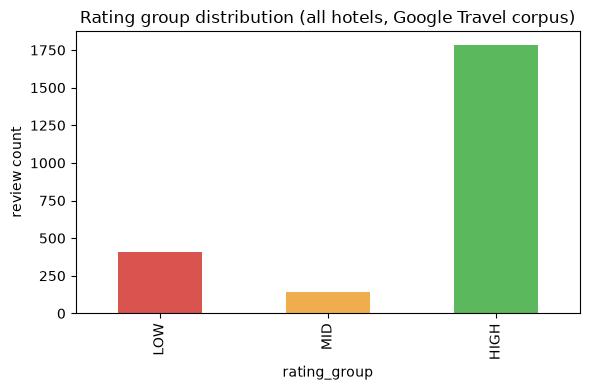

In [6]:

rating_audit = clean["rating_group"].value_counts(dropna=False)
invalid_rating_count = int(clean["quality_flags"].str.contains("INVALID_RATING", na=False).sum())
print("invalid_rating_count:", invalid_rating_count)
rating_audit.to_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_rating_audit.csv")

fig, ax = plt.subplots(figsize=(6,4))
rating_audit.reindex(["LOW","MID","HIGH"]).plot(kind="bar", ax=ax, color=["#d9534f","#f0ad4e","#5cb85c"])
ax.set_title("Rating group distribution (all hotels, Google Travel corpus)")
ax.set_ylabel("review count")
plt.tight_layout()
plt.savefig(FIG_DIR + r"\rating_group_distribution.png", dpi=110)
plt.show()


### Grafik nasıl okunur?
Her çubuk bir puan grubunu (LOW=1-2, MID=3, HIGH=4-5) temsil eder; yükseklik o gruba düşen toplam yorum sayısıdır.
### Ne görüyoruz?
Google Travel korpusunda puan dağılımının hangi uca kaydığı görülür.
### Neden önemli?
Genel memnuniyet eğilimini ve aşırı pozitif/negatif çarpıklığı tek bakışta gösterir.
### Dikkat edilmesi gereken nokta
Bu, tüm otellerin karışık toplamıdır - otel bazlı farklar C bölümünde (EDA) ayrıca ele alınır.

## B12-B13: Source distribution & date audit

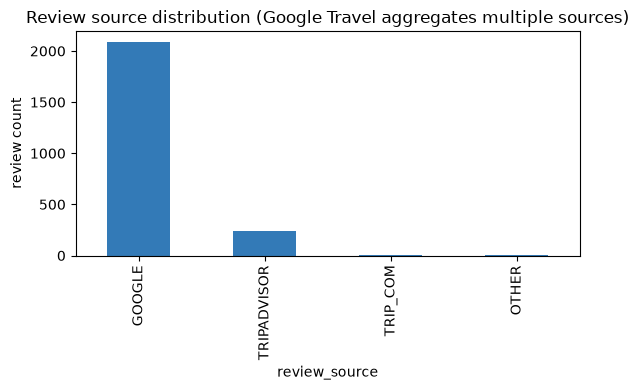

In [7]:

source_counts = clean["review_source"].value_counts()
source_counts.to_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_source_audit.csv")

fig, ax = plt.subplots(figsize=(6,4))
source_counts.plot(kind="bar", ax=ax, color="#337ab7")
ax.set_title("Review source distribution (Google Travel aggregates multiple sources)")
ax.set_ylabel("review count")
plt.tight_layout()
plt.savefig(FIG_DIR + r"\source_distribution.png", dpi=110)
plt.show()


### Grafik nasıl okunur?
Her çubuk, Google Travel panelinin yorumu hangi kaynaktan aldığını (GOOGLE/TRIPADVISOR/TRIP_COM/OTHER) gösterir.
### Ne görüyoruz?
Google Travel review paneli tek kaynaklı değildir - farklı platformlardan toplanan yorumları aynı panelde birleştirir.
### Neden önemli?
"Google Travel review" demek "yalnız Google yorumu" demek değildir; kaynak karışımını bilmeden coverage/comparison yapmak yanıltıcı olur.
### Dikkat edilmesi gereken nokta
review_source, ham 'tarih' metninden parse edilmiştir ve site tarafından etiketlenmiştir - bizim bir varsayımımız değildir.

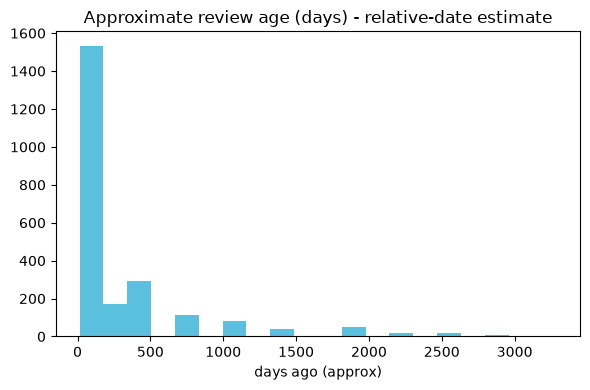

date_coverage_pct: 100.0


In [8]:

age = clean["review_age_days_approx"].dropna()
fig, ax = plt.subplots(figsize=(6,4))
ax.hist(age, bins=20, color="#5bc0de")
ax.set_title("Approximate review age (days) - relative-date estimate")
ax.set_xlabel("days ago (approx)")
plt.tight_layout()
plt.savefig(FIG_DIR + r"\review_age_distribution.png", dpi=110)
plt.show()
print("date_coverage_pct:", round(age.notna().mean()*100, 1) if len(clean) else 0)


## B15: Details (rooms/service/location) coverage

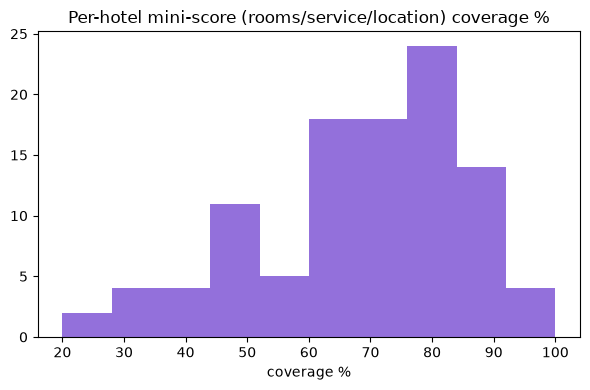

,n_reviews,rooms_score_coverage_pct,service_score_coverage_pct,location_score_coverage_pct
count,104.000000,104.000000,104.000000,104.000000
mean,22.461538,68.318269,68.318269,68.318269
std,18.400044,17.974009,17.974009,17.974009
min,10.000000,20.000000,20.000000,20.000000
25%,10.000000,59.175000,59.175000,59.175000
50%,11.000000,70.000000,70.000000,70.000000
75%,29.000000,80.000000,80.000000,80.000000
max,87.000000,100.000000,100.000000,100.000000


In [9]:

details_coverage = clean.groupby("hotel_id").agg(
    n_reviews=("hotel_id", "size"),
    rooms_score_coverage_pct=("rooms_score", lambda s: round(s.notna().mean()*100, 1)),
    service_score_coverage_pct=("service_score", lambda s: round(s.notna().mean()*100, 1)),
    location_score_coverage_pct=("location_score", lambda s: round(s.notna().mean()*100, 1)),
).reset_index()
details_coverage.to_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_details_coverage.csv", index=False)

fig, ax = plt.subplots(figsize=(6,4))
ax.hist(details_coverage["rooms_score_coverage_pct"], bins=10, color="#9370db")
ax.set_title("Per-hotel mini-score (rooms/service/location) coverage %")
ax.set_xlabel("coverage %")
plt.tight_layout()
plt.savefig(FIG_DIR + r"\details_coverage_by_hotel.png", dpi=110)
plt.show()
details_coverage.describe()


## B16: Hotel corpus imbalance

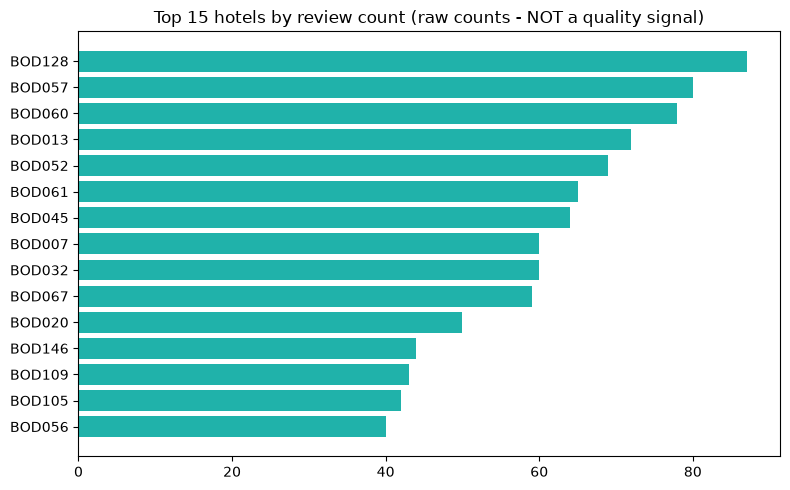

,review_count,share_of_total_pct
count,104.000000,104.000000
mean,22.461538,0.962404
std,18.400044,0.786501
min,10.000000,0.430000
25%,10.000000,0.430000
50%,11.000000,0.470000
75%,29.000000,1.240000
max,87.000000,3.720000


In [10]:

balance = clean.groupby("hotel_id").size().rename("review_count").reset_index()
balance["share_of_total_pct"] = (balance["review_count"] / balance["review_count"].sum() * 100).round(2)
balance = balance.sort_values("review_count", ascending=False)
balance.to_csv(REPO_ROOT + r"\reports\google_travel_all_hotels_hotel_balance.csv", index=False)

fig, ax = plt.subplots(figsize=(8,5))
top15 = balance.head(15)
ax.barh(top15["hotel_id"][::-1], top15["review_count"][::-1], color="#20b2aa")
ax.set_title("Top 15 hotels by review count (raw counts - NOT a quality signal)")
plt.tight_layout()
plt.savefig(FIG_DIR + r"\hotel_corpus_imbalance_top15.png", dpi=110)
plt.show()
balance.describe()


### Grafik nasıl okunur?
En çok yorumu bulunan 15 otel, ham yorum sayısına göre sıralanmıştır.
### Ne görüyoruz?
Oteller arası korpus büyüklüğü ciddi biçimde dengesizdir.
### Neden önemli?
Sonraki karşılaştırmalarda ham sayı yerine oran/rate kullanılması gerektiğini gösterir.
### Dikkat edilmesi gereken nokta
Çok yorum almak "daha iyi otel" anlamına gelmez - yalnızca daha fazla örneklem demektir.

## B17: Language audit (lightweight, rule-based)

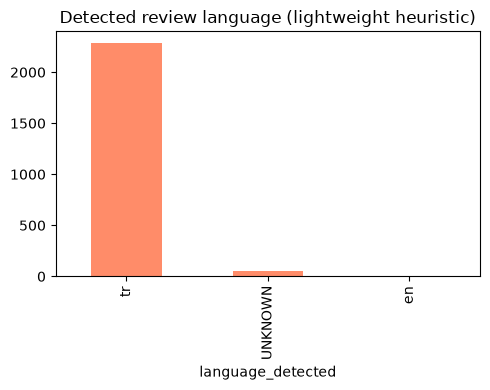

language_detected
tr         2286
UNKNOWN      49
en            1
Name: count, dtype: int64

In [11]:

lang_counts = clean["language_detected"].value_counts()
fig, ax = plt.subplots(figsize=(5,4))
lang_counts.plot(kind="bar", ax=ax, color="#ff8c69")
ax.set_title("Detected review language (lightweight heuristic)")
plt.tight_layout()
plt.savefig(FIG_DIR + r"\language_distribution.png", dpi=110)
plt.show()
lang_counts


## B22: Notebook 12 - Final Answers

In [12]:

answers = {
    "raw_total_rows": int(raw_total),
    "clean_total_rows": int(len(clean)),
    "hotel_count": int(clean['hotel_id'].nunique()),
    "source_distribution": clean['review_source'].value_counts().to_dict(),
    "cross_hotel_duplicate_hash_groups": int(len(dup_audit)),
    "empty_text_dropped_during_cleaning": "see google_travel_all_hotels_audit_summary.txt",
    "invalid_rating_count": invalid_rating_count,
    "rating_coverage_pct": round(clean['review_rating_numeric'].notna().mean()*100, 1),
    "date_coverage_pct": round(clean['review_age_days_approx'].notna().mean()*100, 1),
    "avg_details_coverage_pct": round(details_coverage['rooms_score_coverage_pct'].mean(), 1),
    "largest_corpus_hotel": balance.iloc[0].to_dict() if len(balance) else None,
    "smallest_corpus_hotel": balance.iloc[-1].to_dict() if len(balance) else None,
    "analysis_readiness": "READY for EDA (notebook 13)" if len(clean) > 0 else "NOT READY - no clean rows",
}
for k, v in answers.items():
    print(f"{k}: {v}")


raw_total_rows: 2336
clean_total_rows: 2336
hotel_count: 104
source_distribution: {'GOOGLE': 2088, 'TRIPADVISOR': 243, 'TRIP_COM': 3, 'OTHER': 2}
cross_hotel_duplicate_hash_groups: 0
empty_text_dropped_during_cleaning: see google_travel_all_hotels_audit_summary.txt
invalid_rating_count: 3
rating_coverage_pct: 99.9
date_coverage_pct: 100.0
avg_details_coverage_pct: 68.3
largest_corpus_hotel: {'hotel_id': 'BOD128', 'review_count': 87, 'share_of_total_pct': 3.72}
smallest_corpus_hotel: {'hotel_id': 'BOD180', 'review_count': 10, 'share_of_total_pct': 0.43}
analysis_readiness: READY for EDA (notebook 13)
